# Corruption insertion figures

Figures over the `run_cot_corruption.py` outputs in `data/corrupted/`
(cutoff fractions 0.25 / 0.5 / 0.75 × five token sources):

1. **Manually inserted** numerical tokens per question (`n_injected`) — 3 cutoffs.
2. **Self-inserted** numerical tokens per question — the parenthesized numbers the
   model *in-context-learns* to keep emitting in the regenerated trace — 3 cutoffs.
3. **Pairwise effect of entanglement sign** on fraction correct — `top10` − `bottom10`
   (paired by question) within the correct- and incorrect-answer pools.
4. **Pairwise effect of targeted answer** on fraction correct — `correct` − `incorrect`
   (paired by question) within the `top10` and `bottom10` pools.

Figs 1–2 are averaged across the five insertion sources (per question, then
histogrammed). Launch against the project venv: `uv run jupyter lab`.

In [1]:
# Load .env first (thread caps etc.) per repo convention, before heavy imports.
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(usecwd=True))

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["figure.dpi"] = 200

## Load the corruption runs

`n_injected` is the count of tokens spliced into the kept prefix; it depends only
on the trace and the cutoff, so it is **identical across the five sources**
(averaging over them is a no-op — included only to match the figure spec).
`n_self` counts the `(number)` patterns the model emits *in the regenerated
continuation* (`think_text` excludes the injected prefix), i.e. the insertions the
model picked up on its own — uncorrupted traces have ≈0 of these.

In [2]:
CUTS = [0.25, 0.5, 0.75]
SOURCES = ["correct_top10", "correct_bottom10", "incorrect_top10", "incorrect_bottom10", "random_numerical"]
PAREN = re.compile(r"\(\s*\d+\s*\)")  # the " (N) " injection format the model imitates

CORR = next(p for p in [Path("data/corrupted"), Path("../data/corrupted")] if p.exists())

def load(cut, src):
    "One corruption run, deduped to unique qid, indexed by qid, with a self-insertion count."
    df = pd.read_parquet(CORR / f"corrupted_{cut}_{src}.parquet").drop_duplicates("qid", keep="first")
    df = df.set_index("qid")
    df["n_self"] = df["think_text"].fillna("").map(lambda t: len(PAREN.findall(t)))
    return df

runs = {(c, s): load(c, s) for c in CUTS for s in SOURCES}

def common_qids(cut):
    "qids present in all five sources at this cutoff."
    idx = None
    for s in SOURCES:
        i = runs[(cut, s)].index
        idx = i if idx is None else idx.intersection(i)
    return idx.sort_values()

def per_question_mean(cut, col):
    "Per-qid mean of `col` across the five insertion sources (aligned on common qids)."
    q = common_qids(cut)
    return pd.concat([runs[(cut, s)].loc[q, col] for s in SOURCES], axis=1).mean(axis=1)

def mean_halfci(x, z=1.96):
    "Return (mean, half-width of 95% CI of the mean)."
    x = np.asarray(x, float)
    sem = x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return x.mean(), z * sem

print("loaded", len(runs), "runs;", {c: len(common_qids(c)) for c in CUTS}, "common qids per cutoff")

loaded 15 runs; {0.25: 96, 0.5: 96, 0.75: 96} common qids per cutoff


## Figure 1 — manually inserted numerical tokens

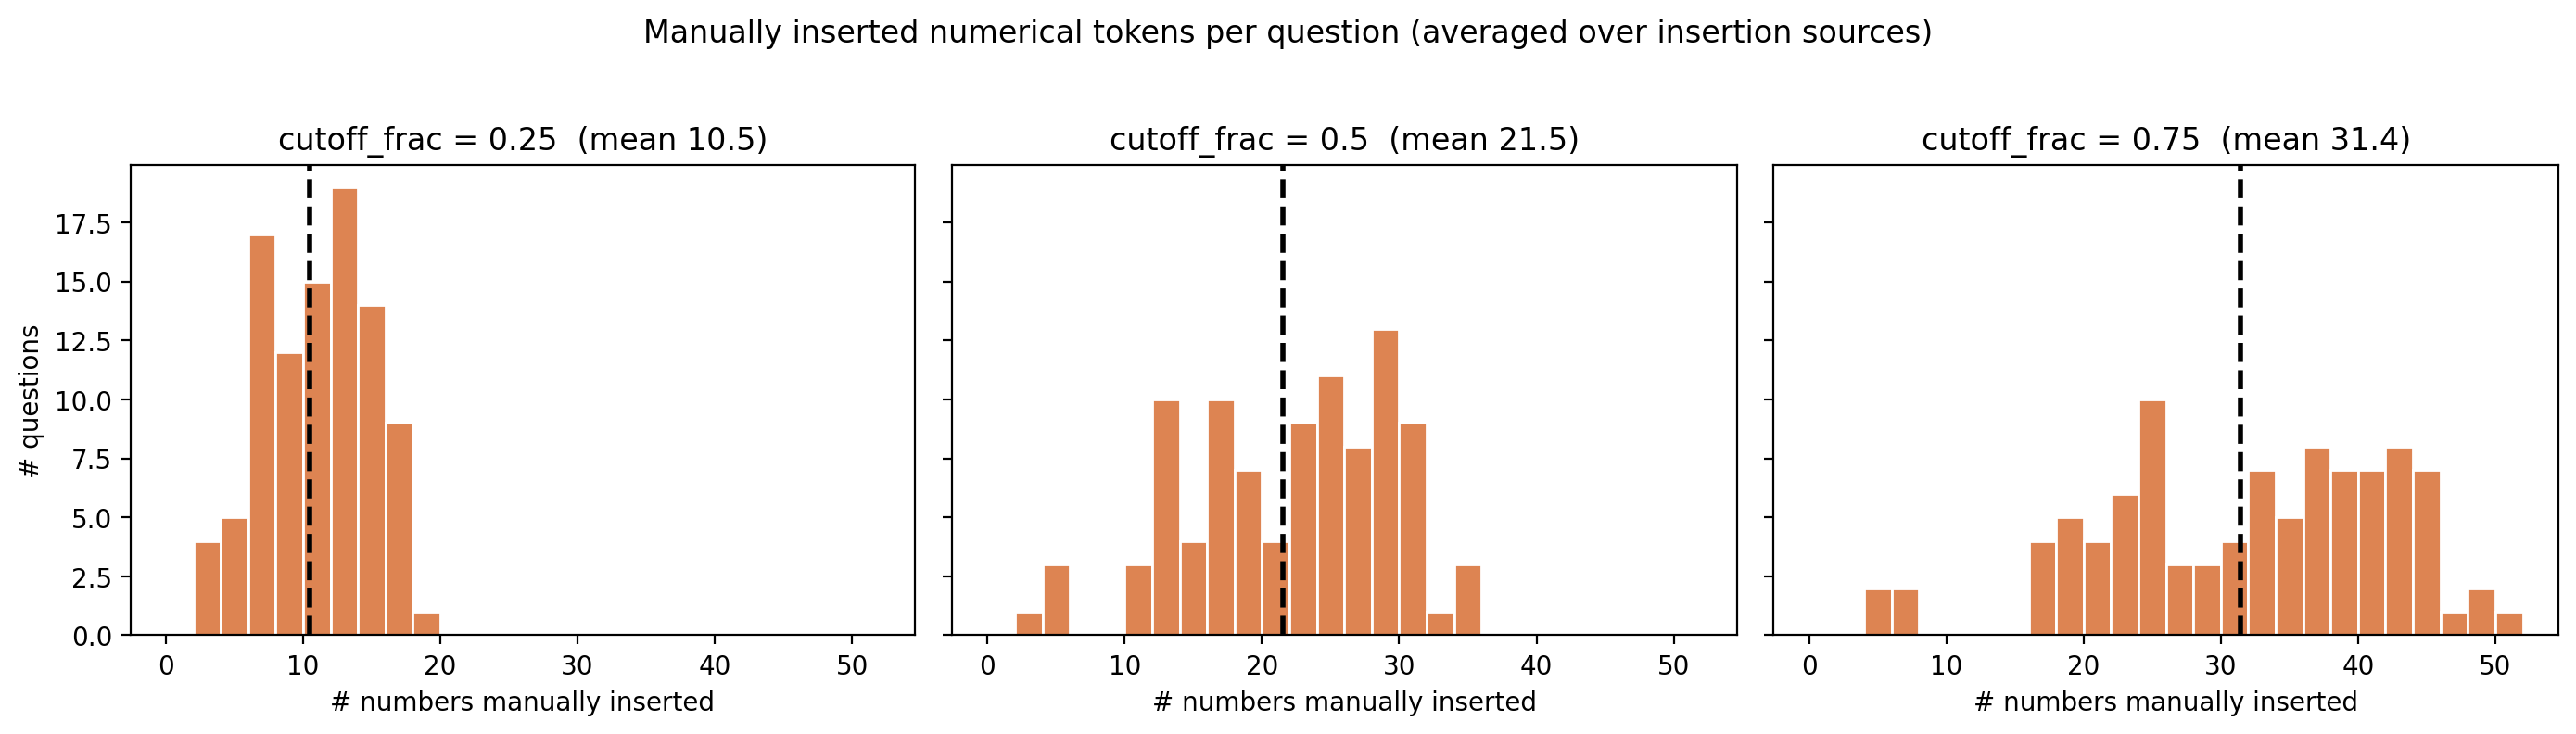

In [3]:
vals = {c: per_question_mean(c, "n_injected") for c in CUTS}
hi = max(v.max() for v in vals.values())
bins = np.arange(0, hi + 3, 2)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
for ax, c in zip(axes, CUTS):
    v = vals[c]
    ax.hist(v, bins=bins, color="#DD8452", edgecolor="white")
    ax.axvline(v.mean(), c="k", lw=2, ls="--")
    ax.set_title(f"cutoff_frac = {c}  (mean {v.mean():.1f})")
    ax.set_xlabel("# numbers manually inserted")
axes[0].set_ylabel("# questions")
fig.suptitle("Manually inserted numerical tokens per question (averaged over insertion sources)", y=1.03)
fig.tight_layout()

## Figure 2 — numbers the model inserted itself (in-context learned)

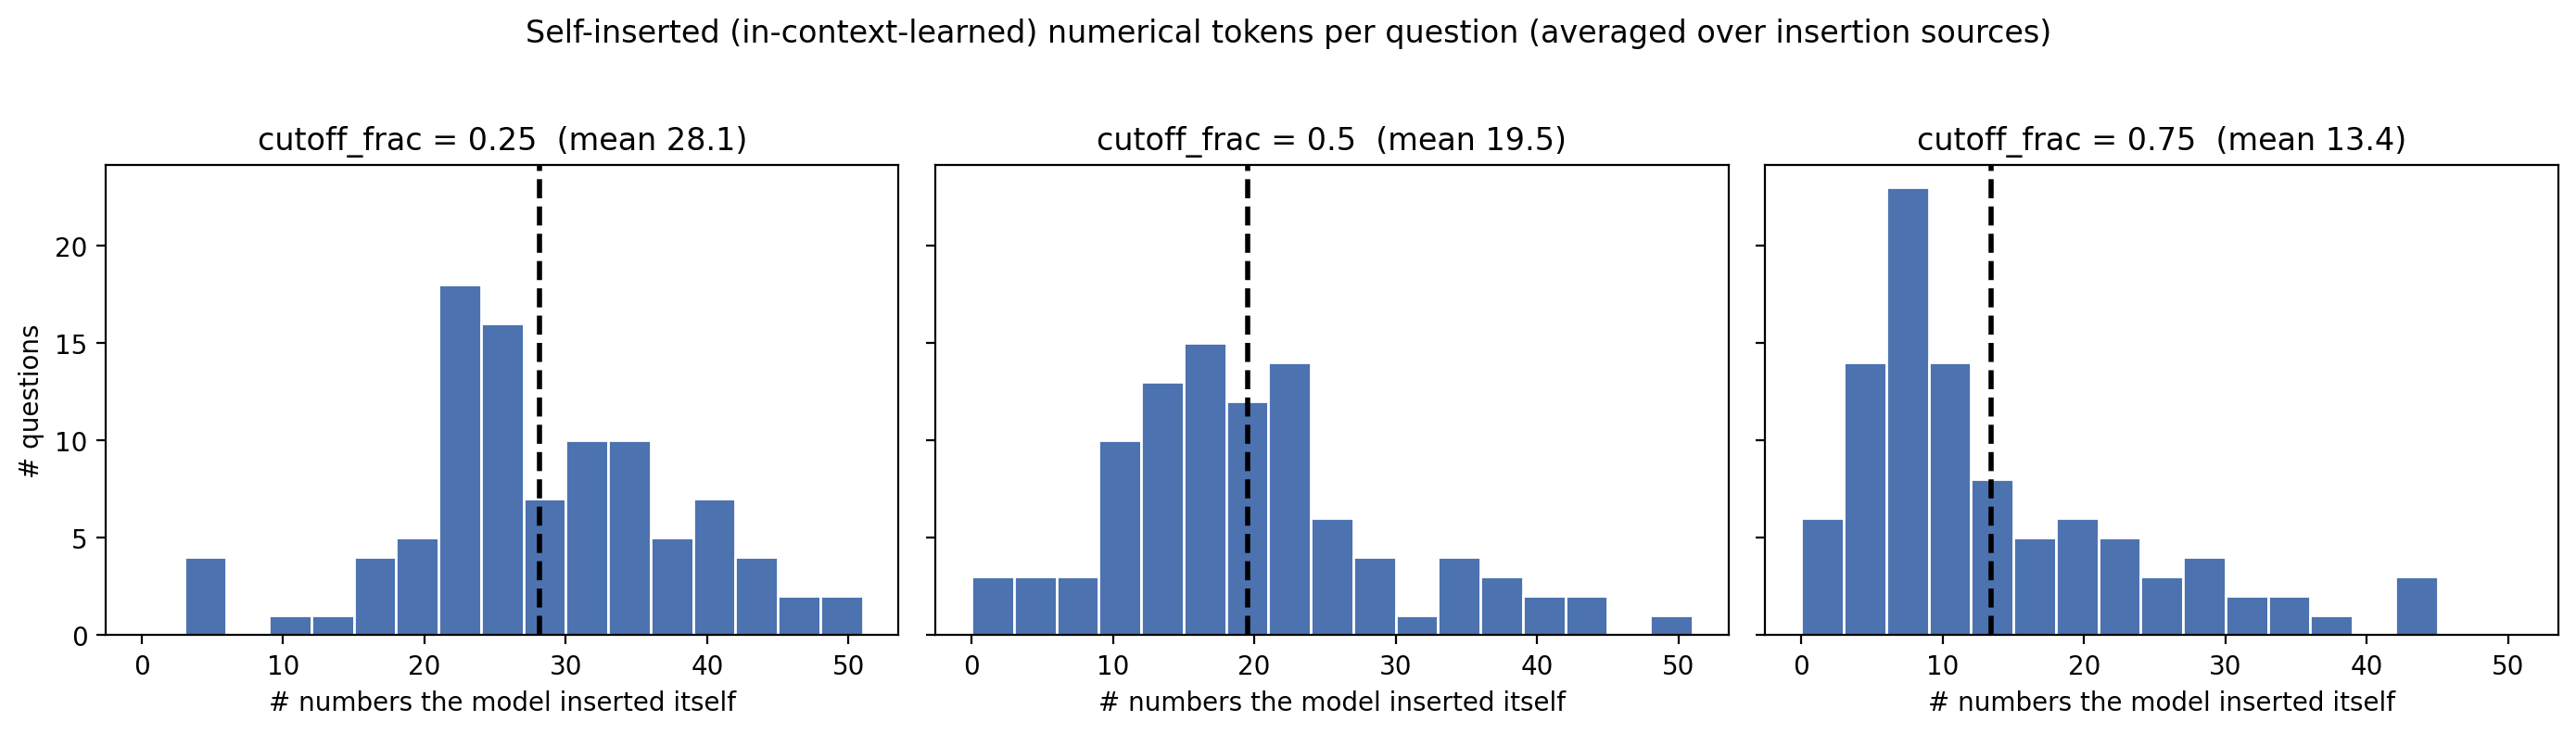

In [4]:
vals = {c: per_question_mean(c, "n_self") for c in CUTS}
hi = max(v.max() for v in vals.values())
bins = np.arange(0, hi + 4, 3)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True)
for ax, c in zip(axes, CUTS):
    v = vals[c]
    ax.hist(v, bins=bins, color="#4C72B0", edgecolor="white")
    ax.axvline(v.mean(), c="k", lw=2, ls="--")
    ax.set_title(f"cutoff_frac = {c}  (mean {v.mean():.1f})")
    ax.set_xlabel("# numbers the model inserted itself")
axes[0].set_ylabel("# questions")
fig.suptitle("Self-inserted (in-context-learned) numerical tokens per question (averaged over insertion sources)", y=1.03)
fig.tight_layout()

## Figure 3 — pairwise effect of entanglement sign (top10 − bottom10)

Within each answer pool, the paired per-question difference between the
positive-entanglement (`top10`) and negative-entanglement (`bottom10`) injections:
**`correct_top10` − `correct_bottom10`** and **`incorrect_top10` − `incorrect_bottom10`**.
The difference is taken per `qid`, so the shared baseline cancels (equivalently, it is
the difference in their change-from-baseline). Bars show the mean with a 95% CI of the
mean paired difference. If entanglement steers as hypothesized, the **correct-pool**
difference is positive (top10 helps more than bottom10) and the **incorrect-pool**
difference is negative (top10 — pushing toward the wrong answer — hurts more than
bottom10). Three subplots, one per cutoff.

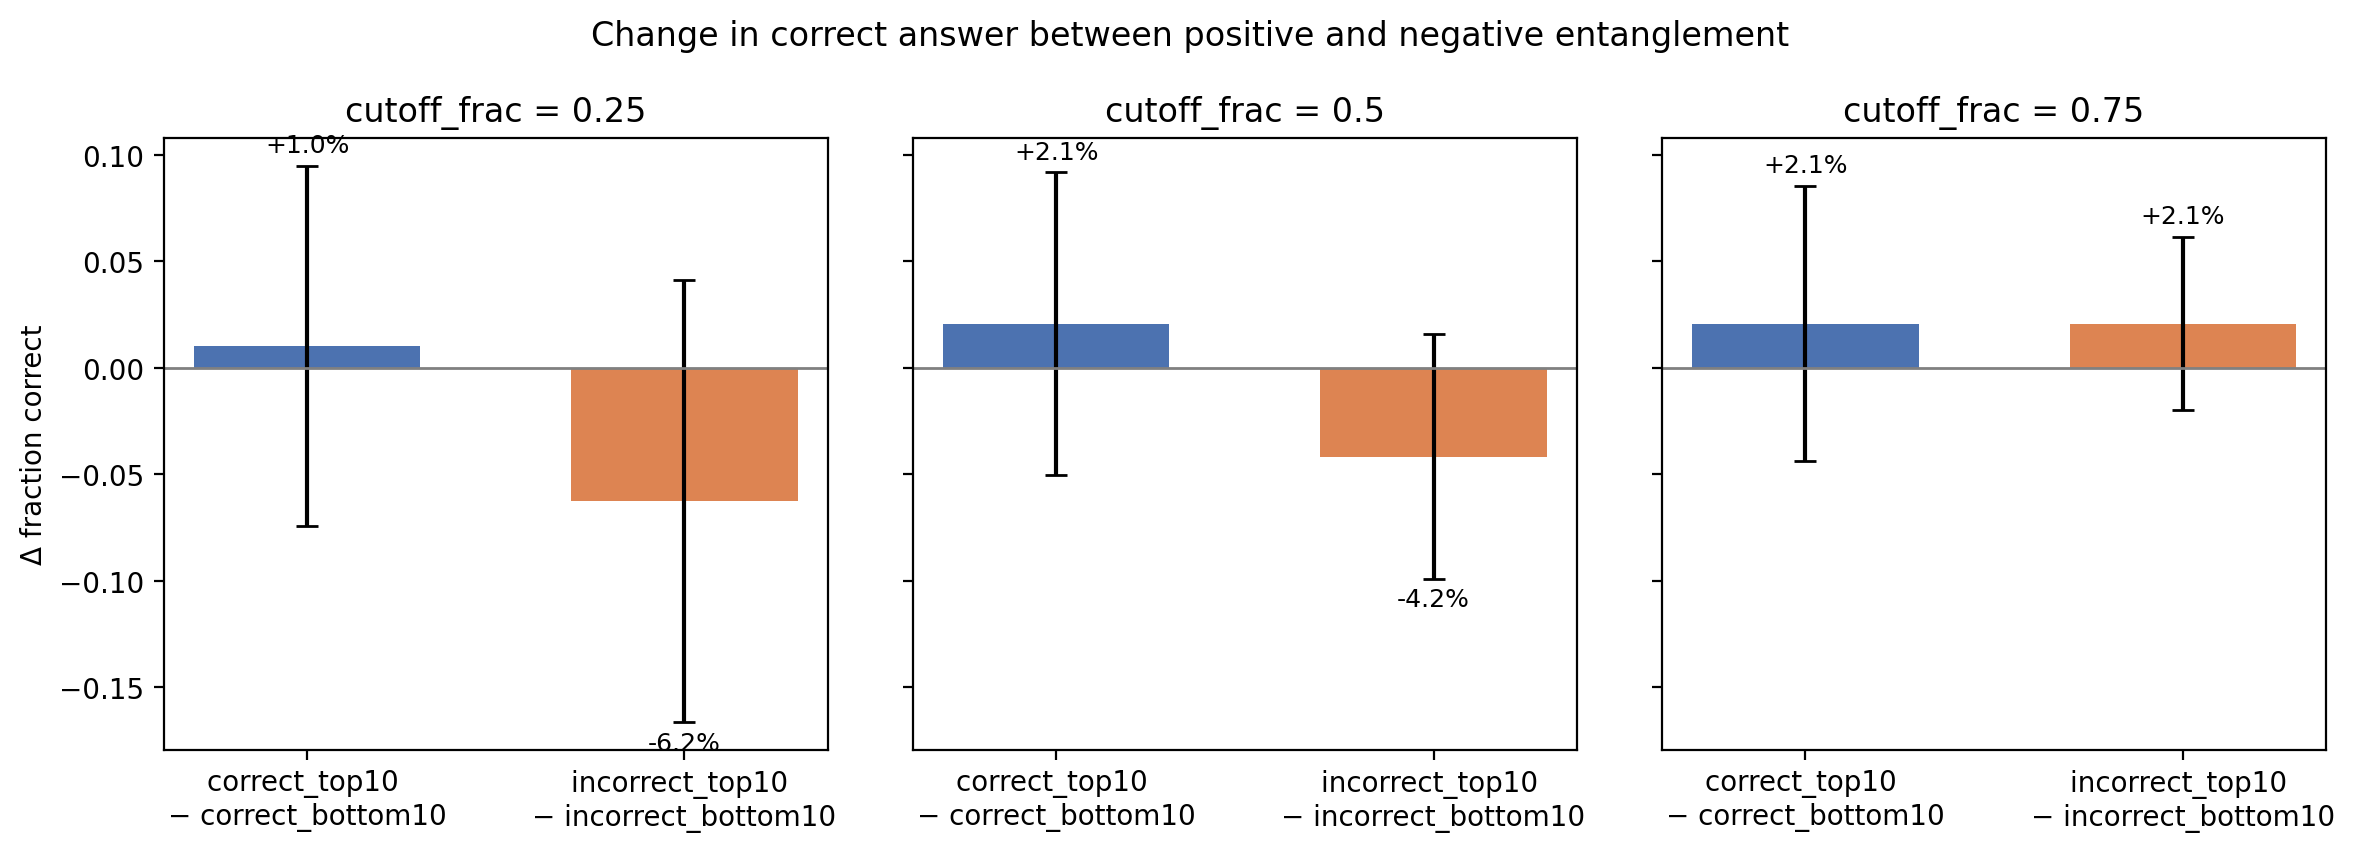

In [5]:
# Pairwise (paired-by-qid) differences within each answer pool: top10 − bottom10.
PAIRS = [("correct_top10",   "correct_bottom10",   "correct_top10 \n− correct_bottom10",   "#4C72B0"),
         ("incorrect_top10", "incorrect_bottom10", "incorrect_top10 \n− incorrect_bottom10", "#DD8452")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), sharey=True)
for ax, c in zip(axes, CUTS):
    q = common_qids(c)
    for x, (top, bot, lab, col) in enumerate(PAIRS):
        # per-question difference (shared baseline cancels) → mean ± 95% CI
        diff = (runs[(c, top)].loc[q, "model_correct"].astype(float)
                - runs[(c, bot)].loc[q, "model_correct"].astype(float)).to_numpy()
        m, e = mean_halfci(diff)
        ax.bar(x, m, width=0.6, color=col, yerr=e, capsize=4)
        y = m + e + 0.004 if m >= 0 else m - e - 0.004
        ax.text(x, y, f"{m:+.1%}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
    ax.axhline(0, c="grey", lw=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([p[2] for p in PAIRS])
    ax.set_title(f"cutoff_frac = {c}")
axes[0].set_ylabel("Δ fraction correct")
fig.suptitle("Change in correct answer between positive and negative entanglement")
fig.tight_layout()

## Figure 4 — same as Figure 3, differenced across the targeted answer

The complementary cut to Figure 3: hold the entanglement *sign* fixed and difference
across the *answer* the pool targets, paired per `qid` — **`correct_top10` −
`incorrect_top10`** and **`correct_bottom10` − `incorrect_bottom10`**. Hypothesis: the
**top10** difference is positive (entangling toward the correct answer beats entangling
toward the incorrect one) and the **bottom10** difference is negative (entangling *away
from* the correct answer is worse than away from the incorrect one). Δ fraction correct,
paired by `qid`, with 95% CIs; three subplots, one per cutoff.

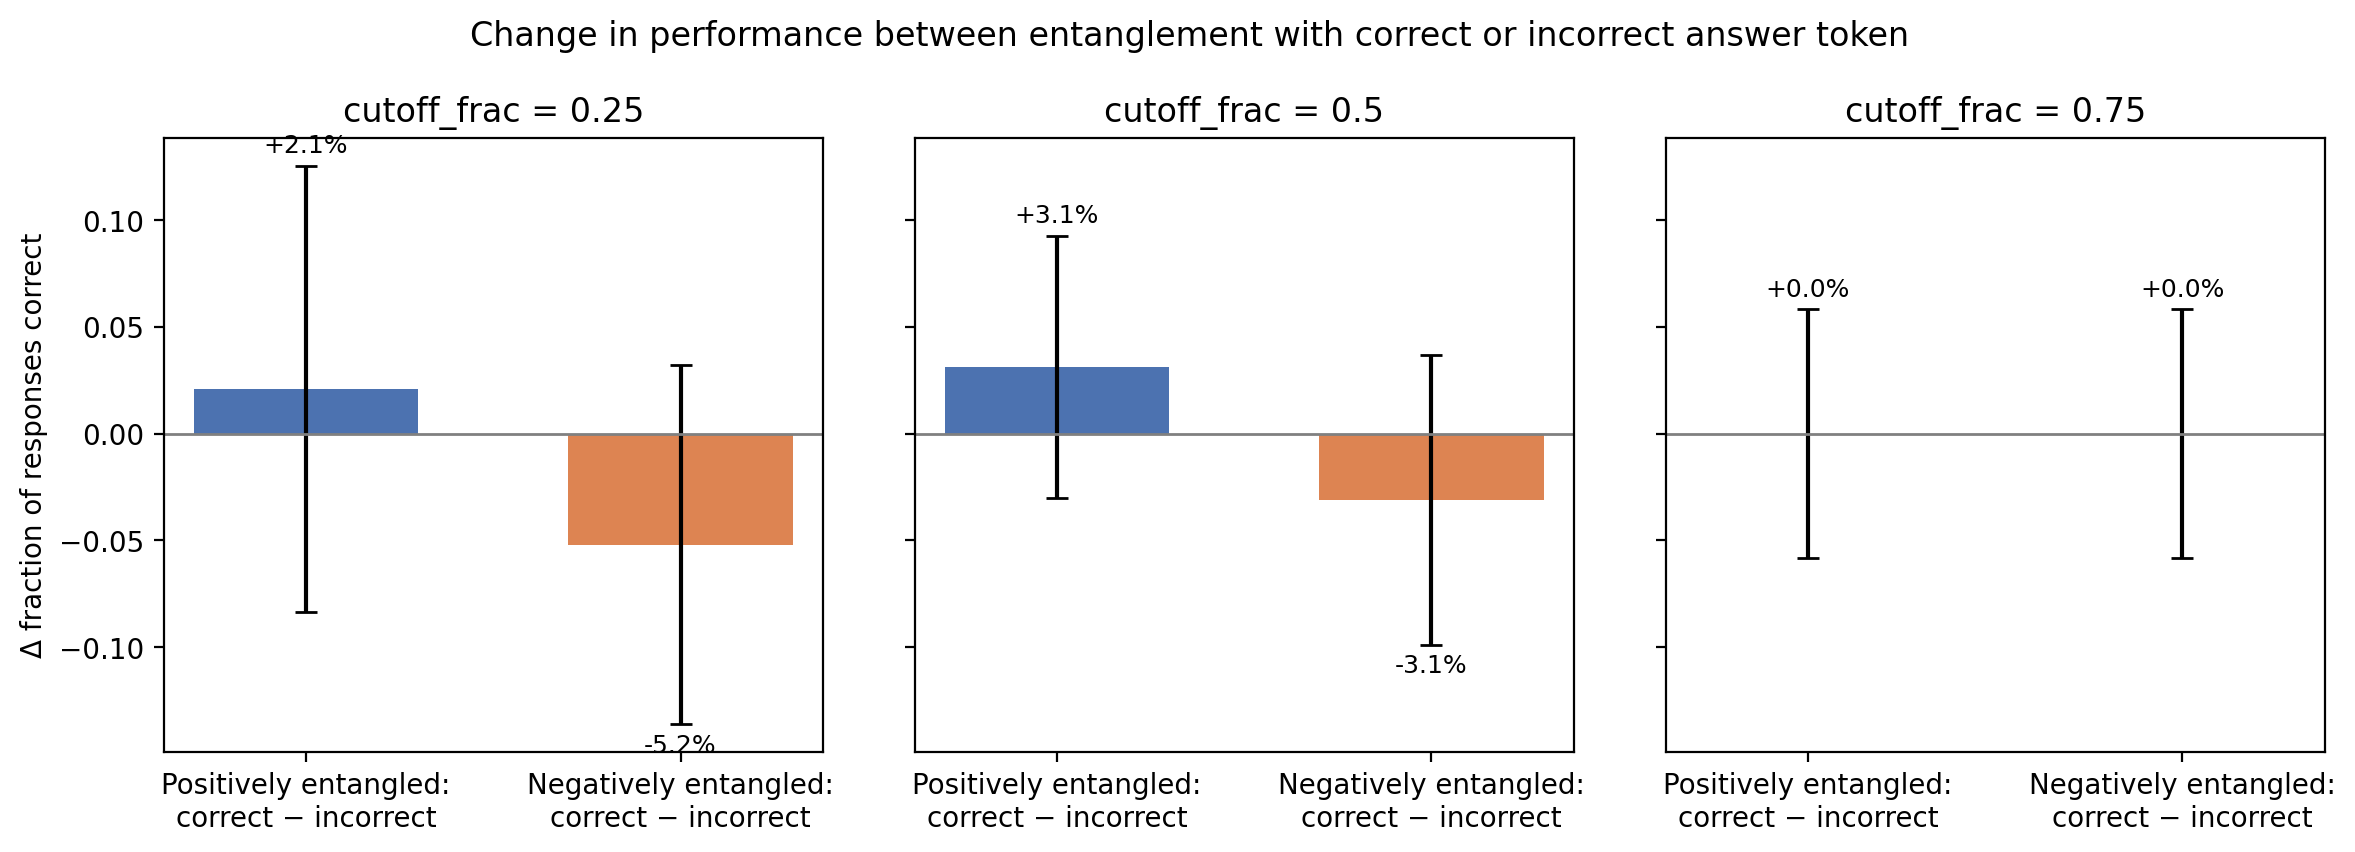

In [6]:
# Figure 4 — pairwise differences across the targeted answer, within each entanglement sign.
PAIRS = [("correct_top10",    "incorrect_top10",    "Positively entangled:\ncorrect − incorrect",       "#4C72B0"),
         ("correct_bottom10", "incorrect_bottom10", "Negatively entangled:\ncorrect − incorrect", "#DD8452")]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), sharey=True)
for ax, c in zip(axes, CUTS):
    q = common_qids(c)
    for x, (a, b, lab, col) in enumerate(PAIRS):
        # per-question difference (shared baseline cancels) → mean ± 95% CI
        diff = (runs[(c, a)].loc[q, "model_correct"].astype(float)
                - runs[(c, b)].loc[q, "model_correct"].astype(float)).to_numpy()
        m, e = mean_halfci(diff)
        ax.bar(x, m, width=0.6, color=col, yerr=e, capsize=4)
        y = m + e + 0.004 if m >= 0 else m - e - 0.004
        ax.text(x, y, f"{m:+.1%}", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
    ax.axhline(0, c="grey", lw=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([p[2] for p in PAIRS])
    ax.set_title(f"cutoff_frac = {c}")
axes[0].set_ylabel("Δ fraction of responses correct")
fig.suptitle("Change in performance between entanglement with correct or incorrect answer token")
fig.tight_layout()